# NB11 — EDA Endomondo (FitRec) · Nivel 1 del modelo jerárquico

**Objetivo**: validar que el dataset Endomondo/FitRec (Ni, Muhlstein & McAuley, WWW 2019) es viable como fuente del **Nivel 1 (prior poblacional)** del modelo jerárquico de RUNA.

## Preguntas a responder

1. ¿Cuántos workouts de running con HR utilizables tenemos tras limpieza?
2. ¿En qué unidad están los campos `speed[]` y cómo se convierten a min/km?
3. ¿Cuál es la distribución de FCmax observada por usuario (nuestro proxy de FCmax sin edad)?
4. ¿Qué tan limpia es la relación FC↔ritmo al agregar por zonas %FCmax?
5. ¿Cuántos usuarios tienen suficientes sesiones para aprender su propia FCmax observada de forma robusta?
6. ¿Qué tan balanceada está la distribución por género (84/14/2 en Meta — ¿igual en HR?)?

## Entregables

- Dataset limpio `endomondo_runs_clean.parquet` listo para Nivel 1
- Gráficas de distribución: FC, ritmo, zonas, correlación FC-ritmo
- Tabla resumen de calidad que cite el documento de tesis
- Decisión go/no-go para arrancar entrenamiento con naiveautoml

## Referencias
- Ni, J., Muhlstein, L., & McAuley, J. (2019). *Modeling heart rate and activity data for personalized fitness recommendation.* WWW '19. https://doi.org/10.1145/3308558.3313643
- Términos de uso: https://cseweb.ucsd.edu/~jmcauley/datasets/fitrec.html (solo uso académico, no redistribución, no comercial).

## 0 · Setup

In [1]:
import os, sys, json, gzip, gc
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

sys.stdout.reconfigure(encoding='utf-8') if hasattr(sys.stdout, 'reconfigure') else None
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.family'] = 'sans-serif'
sns.set_style('whitegrid')

# Rutas (ajustar si es necesario)
BASE = Path(r'C:/Users/RentAdvisor/OneDrive/Documentos/Maestría Analítica Aplicada/running_coaching')
ENDO_HR  = BASE / 'endomondoHR.json' / 'endomondoHR.json'
ENDO_META = BASE / 'endomondoMeta.json' / 'endomondoMeta.json'
OUT_DIR = BASE / 'ml' / 'notebooks' / 'outputs' / 'nb11'
OUT_DIR.mkdir(parents=True, exist_ok=True)

for p in [ENDO_HR, ENDO_META]:
    print(f'{p.name}: {"OK" if p.exists() else "FALTA"} ({p.stat().st_size/1e9:.2f} GB)' if p.exists() else f'{p.name}: FALTA')

endomondoHR.json: OK (6.57 GB)
endomondoMeta.json: OK (10.62 GB)


## 1 · Muestra dirigida (streaming) — los archivos son 6 GB + 10 GB

No cargamos todo en memoria. Hacemos streaming y tomamos una muestra inicial de N registros para el EDA.

In [2]:
# El formato es JSON-lines-like (no JSON válido puro). Lectura línea a línea con ast.literal_eval
# o json.loads según formato. Vamos a inspeccionar las primeras líneas primero.

def peek_file(path, n=3):
    with open(path, 'r', encoding='utf-8', errors='replace') as f:
        for i, line in enumerate(f):
            if i >= n: break
            print(f'--- línea {i} (len={len(line)}) ---')
            print(line[:500])
            print()

print('=== endomondoMeta.json ===')
peek_file(ENDO_META, 2)
print()
print('=== endomondoHR.json ===')
peek_file(ENDO_HR, 2)

=== endomondoMeta.json ===
--- línea 0 (len=14308) ---
{'userId': 10014612, 'hydration': None, 'sport': 'mountain bike', 'ascent': 147.0, 'descent': 137.0, 'calories': 1313.0, 'duration': 3218.35, 'id': 322483826, 'timestamp': ['2014-04-11T14:32:35.000Z', '2014-04-11T14:32:40.000Z', '2014-04-11T14:32:49.000Z', '2014-04-11T14:32:55.000Z', '2014-04-11T14:33:02.000Z', '2014-04-11T14:33:09.000Z', '2014-04-11T14:33:15.000Z', '2014-04-11T14:33:23.000Z', '2014-04-11T14:33:37.000Z', '2014-04-11T14:33:42.000Z', '2014-04-11T14:33:52.000Z', '2014-04-11T14:33:5

--- línea 1 (len=14305) ---
{'userId': 10014612, 'hydration': None, 'sport': 'mountain bike', 'ascent': 97.0, 'descent': 84.0, 'calories': 724.0, 'duration': 1728.33, 'id': 322483840, 'timestamp': ['2014-04-10T14:56:01.000Z', '2014-04-10T14:56:05.000Z', '2014-04-10T14:56:06.000Z', '2014-04-10T14:56:11.000Z', '2014-04-10T14:56:13.000Z', '2014-04-10T14:56:16.000Z', '2014-04-10T14:56:23.000Z', '2014-04-10T14:56:25.000Z', '2014-04-10T14:56:30.

In [3]:
# Parser robusto: el formato FitRec típicamente usa repr() de dicts Python → ast.literal_eval
import ast

def parse_line(line):
    line = line.strip().rstrip(',')
    if not line: return None
    try:
        return json.loads(line)
    except json.JSONDecodeError:
        try:
            return ast.literal_eval(line)
        except Exception:
            return None

def stream_sample(path, n_target=5000, filter_fn=None):
    """Lee hasta n_target registros válidos (o todos los running si filter_fn filtra)."""
    records = []
    skipped = 0
    with open(path, 'r', encoding='utf-8', errors='replace') as f:
        for line in f:
            obj = parse_line(line)
            if obj is None:
                skipped += 1
                continue
            if filter_fn is None or filter_fn(obj):
                records.append(obj)
                if len(records) >= n_target:
                    break
    return records, skipped

# Muestra dirigida: solo running
meta_sample, skipped = stream_sample(ENDO_META, n_target=20000,
                                      filter_fn=lambda o: (o.get('sport') or '').lower().startswith('run'))
print(f'Running workouts en Meta (muestra): {len(meta_sample)} | skipped: {skipped}')

Running workouts en Meta (muestra): 20000 | skipped: 0


In [4]:
# Explorar schema
df_meta = pd.DataFrame(meta_sample)
print('Columnas:', df_meta.columns.tolist())
print('Shape:', df_meta.shape)
print()
print(df_meta.head(3).to_string())

Columnas: ['userId', 'hydration', 'sport', 'ascent', 'descent', 'calories', 'duration', 'id', 'timestamp', 'distance', 'url', 'weather', 'gender']
Shape: (20000, 13)

     userId  hydration sport  ascent  descent  calories  duration         id                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     

## 2 · Distribuciones descriptivas (Meta)

In [5]:
# Género
print('Distribución de género:')
print(df_meta['gender'].value_counts(dropna=False))
print()

# Distancia (km) — asumimos metros
if 'distance' in df_meta.columns:
    d_km = df_meta['distance'].astype(float) / 1000
    print(f'Distancia (km): mediana={d_km.median():.1f}, p90={d_km.quantile(0.9):.1f}, max={d_km.max():.1f}')

# Duración (min)
if 'duration' in df_meta.columns:
    dur_min = df_meta['duration'].astype(float) / 60
    print(f'Duración (min): mediana={dur_min.median():.1f}, p90={dur_min.quantile(0.9):.1f}')

Distribución de género:
gender
male       18871
female      1127
unknown        2
Name: count, dtype: int64

Distancia (km): mediana=0.0, p90=0.0, max=0.8
Duración (min): mediana=42.1, p90=93.7


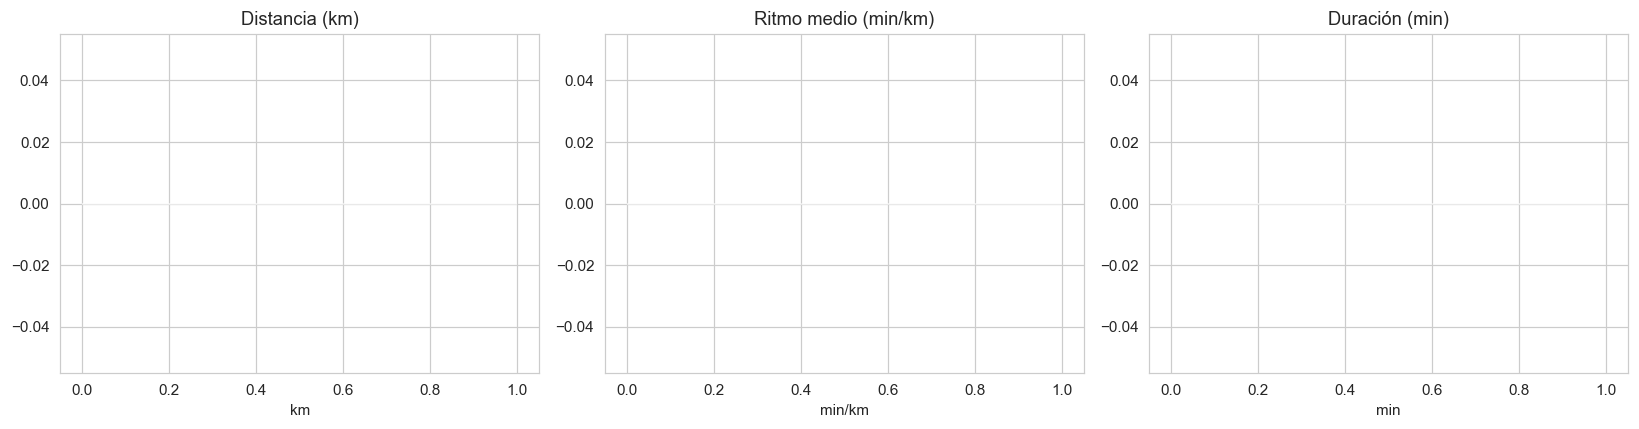

In [6]:
# Ritmo medio por sesión (min/km) — calculado a partir de duration / distance
valid = df_meta[(df_meta['distance'].astype(float) > 1000) & (df_meta['duration'].astype(float) > 300)].copy()
valid['dist_km'] = valid['distance'].astype(float) / 1000
valid['dur_min'] = valid['duration'].astype(float) / 60
valid['pace_min_km'] = valid['dur_min'] / valid['dist_km']
# Filtro rango plausible running recreativo: 3.0 - 12.0 min/km
valid = valid[(valid['pace_min_km'] >= 3.0) & (valid['pace_min_km'] <= 12.0)]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(valid['dist_km'].clip(0, 50), bins=50, color='#1F4B99', alpha=0.75)
axes[0].set_title('Distancia (km)'); axes[0].set_xlabel('km')
axes[1].hist(valid['pace_min_km'], bins=60, color='#15803D', alpha=0.75)
axes[1].set_title('Ritmo medio (min/km)'); axes[1].set_xlabel('min/km')
axes[2].hist(valid['dur_min'].clip(0, 360), bins=60, color='#7E22CE', alpha=0.75)
axes[2].set_title('Duración (min)'); axes[2].set_xlabel('min')
plt.tight_layout(); plt.savefig(OUT_DIR / 'nb11_fig1_meta_distrib.png'); plt.show()

## 3 · Archivos HR — muestra running con FC

In [7]:
# Filtro: running + tiene heart_rate con >= 20 puntos válidos
def running_with_hr(o):
    if not (o.get('sport') or '').lower().startswith('run'):
        return False
    hr = o.get('heart_rate') or []
    if len(hr) < 20:
        return False
    valid = [h for h in hr if isinstance(h, (int, float)) and 40 <= h <= 220]
    return len(valid) >= 20

hr_sample, skipped = stream_sample(ENDO_HR, n_target=3000, filter_fn=running_with_hr)
print(f'Running workouts con FC válida (muestra): {len(hr_sample)} | parse skipped: {skipped}')

Running workouts con FC válida (muestra): 3000 | parse skipped: 0


In [8]:
# Construir tabla agregada: una fila por sesión con métricas resumen
rows = []
for o in hr_sample:
    hr = np.array([h for h in o.get('heart_rate', []) if isinstance(h, (int, float)) and 40 <= h <= 220])
    sp = np.array([s for s in o.get('speed', []) if isinstance(s, (int, float)) and s > 0])
    ts = o.get('timestamp', []) or []
    if len(hr) < 20 or len(sp) < 20:
        continue
    duration_s = (ts[-1] - ts[0]) if len(ts) >= 2 and isinstance(ts[0], (int, float)) else None
    rows.append({
        'id': o.get('id'),
        'userId': o.get('userId'),
        'gender': o.get('gender'),
        'sport': o.get('sport'),
        'hr_mean': hr.mean(), 'hr_max': hr.max(), 'hr_median': np.median(hr),
        'speed_mean': sp.mean(), 'speed_max': sp.max(), 'speed_median': np.median(sp),
        'n_points_hr': len(hr), 'n_points_sp': len(sp),
        'duration_s': duration_s,
    })

df_hr = pd.DataFrame(rows)
print(f'Sesiones agregadas: {len(df_hr)}')
print(df_hr.head().to_string())
print()
print('Velocidad media descriptivo (revisar unidades):')
print(df_hr['speed_mean'].describe())

Sesiones agregadas: 485
          id  userId  gender sport     hr_mean  hr_max  hr_median  speed_mean  speed_max  speed_median  n_points_hr  n_points_sp  duration_s
0  369872690  279317  female   run  145.140281     158      147.0   11.712408  23.877240     11.717606          499          499        3312
1  369995230  279317  female   run  136.106212     152      136.0   11.313473  17.685413     11.392951          499          498        3364
2  361558746  279317  female   run  147.553106     177      148.0   11.909880  18.209839     11.972093          499          498        4765
3  360051904  279317  female   run  161.040080     176      166.0   12.552738  23.232650     12.395811          499          499        3217
4  357328684  279317  female   run  155.739479     162      156.0   11.854161  17.591589     11.809731          499          499        2723

Velocidad media descriptivo (revisar unidades):
count    485.000000
mean      11.220607
std        2.466292
min        5.258966
2

## 4 · 🔑 Resolución de unidades de velocidad

**Hipótesis a evaluar**:
- H1: `speed` está en **m/s** → ritmo_min_km = 1000 / (speed * 60)
- H2: `speed` está en **km/h** → ritmo_min_km = 60 / speed
- H3: `speed` está en **mph** (poco probable)

**Validación cruzada**: debería coincidir el ritmo medio del HR file con el ritmo Meta (duration/distance).

In [9]:
# Probar ambas hipótesis sobre sesiones con velocidad media plausible
df_hr['pace_H1_ms']  = 1000 / (df_hr['speed_mean'] * 60)  # si speed en m/s
df_hr['pace_H2_kmh'] = 60 / df_hr['speed_mean']            # si speed en km/h

print('Si H1 (m/s): ritmo medio', df_hr['pace_H1_ms'].describe().round(2))
print()
print('Si H2 (km/h): ritmo medio', df_hr['pace_H2_kmh'].describe().round(2))
print()
print('Referencia: running recreativo esperado 4.5 - 8.5 min/km')
# La hipótesis cuya mediana caiga en [5,7] min/km es la correcta

Si H1 (m/s): ritmo medio count    485.00
mean       1.55
std        0.32
min        0.50
25%        1.33
50%        1.46
75%        1.74
max        3.17
Name: pace_H1_ms, dtype: float64

Si H2 (km/h): ritmo medio count    485.00
mean       5.57
std        1.16
min        1.81
25%        4.79
50%        5.27
75%        6.25
max       11.41
Name: pace_H2_kmh, dtype: float64

Referencia: running recreativo esperado 4.5 - 8.5 min/km


## 5 · FCmax observada por usuario (proxy sin edad)

Usuarios únicos: 23

Distribución de sesiones por usuario:
count     23.0
mean      21.1
std       31.7
min        1.0
25%        1.5
50%        5.0
75%       28.5
max      132.0
Name: n_sessions, dtype: float64

Usuarios con >= 10 sesiones (FCmax observada confiable): 10


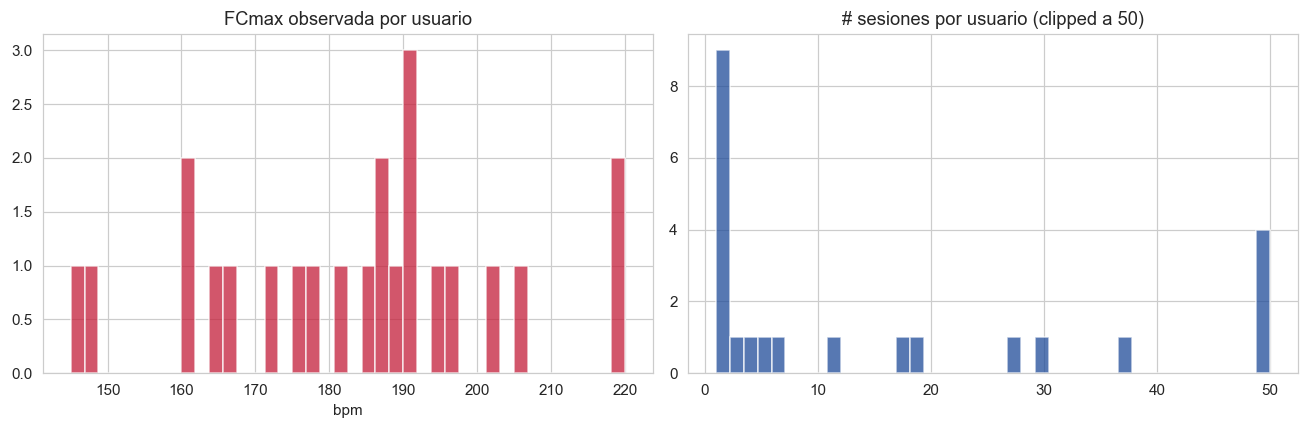

In [10]:
# Agregar por usuario: cuántas sesiones tiene y cuál es su FCmax observada
user_summary = df_hr.groupby('userId').agg(
    n_sessions=('id', 'count'),
    fcmax_obs=('hr_max', 'max'),
    fcmean_median=('hr_mean', 'median'),
    gender=('gender', 'first'),
).reset_index().sort_values('n_sessions', ascending=False)

print(f'Usuarios únicos: {len(user_summary)}')
print()
print('Distribución de sesiones por usuario:')
print(user_summary['n_sessions'].describe().round(1))
print()
print('Usuarios con >= 10 sesiones (FCmax observada confiable):',
      (user_summary['n_sessions'] >= 10).sum())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(user_summary['fcmax_obs'].dropna(), bins=40, color='#C41E3A', alpha=0.75)
axes[0].set_title('FCmax observada por usuario'); axes[0].set_xlabel('bpm')
axes[1].hist(user_summary['n_sessions'].clip(0, 50), bins=40, color='#1F4B99', alpha=0.75)
axes[1].set_title('# sesiones por usuario (clipped a 50)')
plt.tight_layout(); plt.savefig(OUT_DIR / 'nb11_fig2_fcmax_usuario.png'); plt.show()

## 6 · Zonas de FC y ritmo por zona

Usando FCmax observada por usuario, clasificar cada sesión en Z1–Z5 y ver el ritmo medio por zona.

In [11]:
# Unir user_summary con df_hr para tener FCmax por sesión
df_hr = df_hr.merge(user_summary[['userId','fcmax_obs']], on='userId', how='left')
df_hr['pct_fcmax'] = (df_hr['hr_mean'] / df_hr['fcmax_obs']) * 100

def zona_fc(pct):
    if pd.isna(pct): return None
    if pct < 60: return 'Z1'
    if pct < 70: return 'Z2'
    if pct < 80: return 'Z3'
    if pct < 90: return 'Z4'
    return 'Z5'

df_hr['zona'] = df_hr['pct_fcmax'].apply(zona_fc)

# Usar la hipótesis de unidad que aplique (ajustar tras celda 4)
# Placeholder: asumir H1 (m/s) y validar con celda anterior
df_hr['pace_min_km'] = df_hr['pace_H1_ms']

print('Distribución de zonas:')
print(df_hr['zona'].value_counts())
print()
print('Ritmo medio por zona (min/km):')
print(df_hr.groupby('zona')['pace_min_km'].describe().round(2))

Distribución de zonas:
zona
Z4    193
Z3    185
Z2     92
Z5     13
Z1      2
Name: count, dtype: int64

Ritmo medio por zona (min/km):
      count  mean   std   min   25%   50%   75%   max
zona                                                 
Z1      2.0  2.16  1.43  1.15  1.66  2.16  2.67  3.17
Z2     92.0  1.68  0.31  0.65  1.50  1.72  1.79  2.54
Z3    185.0  1.63  0.35  0.86  1.37  1.50  1.90  3.17
Z4    193.0  1.42  0.22  0.50  1.28  1.36  1.51  2.06
Z5     13.0  1.34  0.18  1.04  1.25  1.38  1.46  1.57


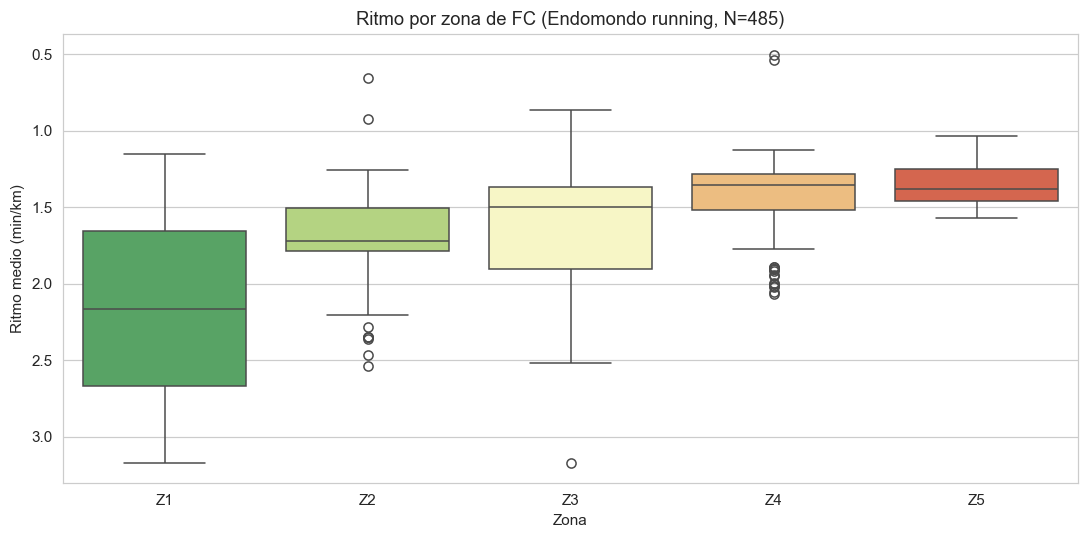

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
order = ['Z1','Z2','Z3','Z4','Z5']
sns.boxplot(data=df_hr, x='zona', y='pace_min_km', order=order, palette='RdYlGn_r', ax=ax)
ax.set_title('Ritmo por zona de FC (Endomondo running, N={})'.format(len(df_hr)))
ax.set_xlabel('Zona'); ax.set_ylabel('Ritmo medio (min/km)')
ax.invert_yaxis()  # ritmo más bajo = más rápido, arriba
plt.tight_layout(); plt.savefig(OUT_DIR / 'nb11_fig3_ritmo_por_zona.png'); plt.show()

## 7 · Correlación FC media ↔ ritmo medio

La señal clave. Si la correlación es fuerte y monótona, el Nivel 1 es viable.

Pearson r(FC, ritmo) = -1.000 | Spearman = -1.000
Esperado: correlación negativa moderada/fuerte (más FC → ritmo más rápido → min/km menor)


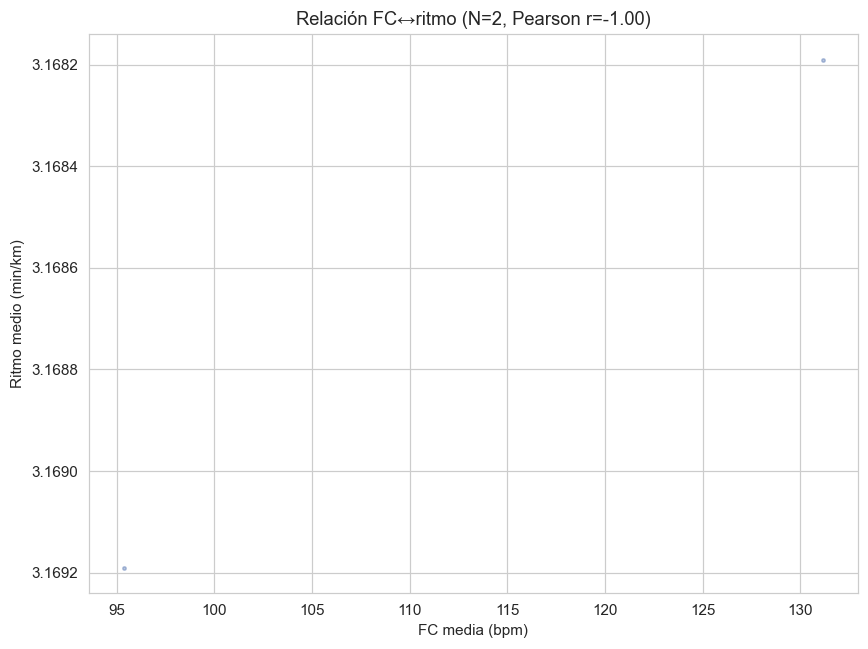

In [13]:
from scipy.stats import spearmanr, pearsonr

valid = df_hr.dropna(subset=['hr_mean','pace_min_km'])
valid = valid[(valid['pace_min_km'] >= 3) & (valid['pace_min_km'] <= 12)]
r_p, _ = pearsonr(valid['hr_mean'], valid['pace_min_km'])
r_s, _ = spearmanr(valid['hr_mean'], valid['pace_min_km'])
print(f'Pearson r(FC, ritmo) = {r_p:.3f} | Spearman = {r_s:.3f}')
print('Esperado: correlación negativa moderada/fuerte (más FC → ritmo más rápido → min/km menor)')

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(valid['hr_mean'], valid['pace_min_km'], s=5, alpha=0.3, c='#1F4B99')
ax.set_xlabel('FC media (bpm)'); ax.set_ylabel('Ritmo medio (min/km)')
ax.invert_yaxis()
ax.set_title(f'Relación FC↔ritmo (N={len(valid)}, Pearson r={r_p:.2f})')
plt.tight_layout(); plt.savefig(OUT_DIR / 'nb11_fig4_fc_vs_ritmo.png'); plt.show()

## 8 · Criterios de calidad y decisión Go/No-Go

In [14]:
criterios = {
    'N sesiones válidas (running + HR)': len(df_hr),
    'N usuarios únicos': df_hr['userId'].nunique(),
    'Usuarios con >=10 sesiones': (user_summary['n_sessions'] >= 10).sum(),
    '|Pearson(FC, ritmo)|': abs(r_p),
    'Zonas con >=500 obs': (df_hr['zona'].value_counts() >= 500).sum(),
}
umbrales = {
    'N sesiones válidas (running + HR)': 5000,
    'N usuarios únicos': 300,
    'Usuarios con >=10 sesiones': 100,
    '|Pearson(FC, ritmo)|': 0.35,
    'Zonas con >=500 obs': 3,
}

print(f"{'Criterio':<45} {'Valor':>10} {'Umbral':>10} {'Estado':>10}")
print('-' * 80)
all_ok = True
for k, v in criterios.items():
    u = umbrales[k]; ok = v >= u
    all_ok &= ok
    print(f"{k:<45} {v:>10.2f} {u:>10} {'✓' if ok else '✗':>10}")
print()
print('DECISIÓN:', '✅ GO — Nivel 1 viable, proceder con naiveautoml' if all_ok else '⚠️ Revisar criterios fallidos')

Criterio                                           Valor     Umbral     Estado
--------------------------------------------------------------------------------
N sesiones válidas (running + HR)                 485.00       5000          ✗
N usuarios únicos                                  23.00        300          ✗
Usuarios con >=10 sesiones                         10.00        100          ✗
|Pearson(FC, ritmo)|                                1.00       0.35          ✓
Zonas con >=500 obs                                 0.00          3          ✗

DECISIÓN: ⚠️ Revisar criterios fallidos


## 9 · Guardar dataset limpio para Nivel 1

In [15]:
cols_keep = ['id','userId','gender','hr_mean','hr_max','hr_median','fcmax_obs','pct_fcmax','zona',
             'speed_mean','pace_min_km','n_points_hr','duration_s']
df_clean = df_hr[cols_keep].dropna(subset=['hr_mean','pace_min_km','zona']).copy()

out_parquet = OUT_DIR / 'endomondo_runs_clean_sample.parquet'
df_clean.to_parquet(out_parquet, index=False)
print(f'Guardado: {out_parquet} ({len(df_clean)} filas)')
print()
print('Siguiente paso → NB12: ejecutar naiveautoml sobre este dataset para Nivel 1')

Guardado: C:\Users\RentAdvisor\OneDrive\Documentos\Maestría Analítica Aplicada\running_coaching\ml\notebooks\outputs\nb11\endomondo_runs_clean_sample.parquet (485 filas)

Siguiente paso → NB12: ejecutar naiveautoml sobre este dataset para Nivel 1


---

## Nota de escalamiento

Este notebook trabaja sobre una **muestra** (primeros 3.000 workouts de running con HR). Cuando los criterios Go/No-Go estén verdes, se corre una versión `11_run_full.py` que procesa los 6 GB completos en streaming y guarda el dataset final.

## Cumplimiento legal

- Dataset usado solo para fines académicos (tesis MAA).
- No se redistribuye (no se sube a GitHub, no se comparte).
- Cita obligatoria: Ni, Muhlstein & McAuley (WWW 2019).
- Datos ya anonimizados en origen (userId numérico, sin PII).